In [79]:
# Alex Medina
# AST 5765 
# Final Project
# 8 November 2025

In [80]:
# Imports
import os
import disk as d
import numpy as np
import gaussian as g
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from astropy.stats import sigma_clip

In [81]:
print('Problem 1) \n')
print('Completed on log. \n')

Problem 1) 

Completed on log. 



In [82]:
print('Problem 2) \n')
print('Completed on log. \n')

Problem 2) 

Completed on log. 



In [83]:
print('Problem 3 \n')

Problem 3 



In [84]:
# Directory variables
datadir   = 'data/'
fext      = '.fits'

datafiles = []
for filename in os.listdir(datadir):
    if filename.startswith('SPITZER'):
        file =filename.split(fext)[0]
        datafiles.append(file)

datafiles = sorted(datafiles) # filenames
nfiles    = len(datafiles)    # number of files

# Array varriables
setn_col  = 0   # number of SPITZER file
locf_col  = 1   # local frame number (within SPITZER file)
glof_col  = 2   # global frame number (over all files)
date_col  = 3   # mid-time of the frame (MJD in days)
mbkg_col  = 4   # median background value
ycen_col  = 5   # fitted y center coordinate in pixels
xcen_col  = 6   # fitted x center coordinate in pixels
widt_col  = 7   # gaussian width in pixels
flux_col  = 8   # total aperture flux
asky_col  = 9   # average sky value
nbad_col  = 10  # number of bad pixels in frame

# General variables
clip_sig  = 5.0   # for sigma clipping routine
max_iter  = 2     # number of iterations for sigma clipping
clipaxis  = 1     # axis to clip
ssize     = 4     # pixel subsize
transit_b = 12000 # frame where transit begins (with some space)
transit_e = 35000 # frame where transit ends ( with some space)

In [85]:
print(f'The data directory is: {datadir} \n')

The data directory is: data/ 



In [86]:
print('Problem 4 \n')

Problem 4 



In [87]:
# a) Read first block for relevant information
infofile   = fits.getdata(datadir + datafiles[0] + fext)
nf, nx, ny = infofile.shape
print(f'There are {nf} frames per subarray set.')

# b) Datacube and photometry array
totframes  = nfiles * nf
datacube   = np.zeros((totframes, nx, ny))
print(f'The shape of the datacube: {datacube.shape}')

nparams    = 11  # number of parameters in photometry array
photometry = np.zeros((totframes, nparams))
print(f'The shape of the photometry array: {photometry.shape}')

# c) Main routine
def read_sets(startset, endset, datarr, photarr):
    """
    Loop over SPITZER frames starting at a given global subarray set number (frame index) and ending at another (inclusive).

    Parameters
    ----------
    startset : int
        global frame number from which to begin allocating data
    endset : int
        global frame number from which to end allocating data (inclusive)
    datarr : ndarray
        empty datacube to store data
    photarr : ndarray
        array to store photometry numbers
    
    Returns
    -------
        Updated datacube and array for specified subset of frames
    """
    # Each SPITZER subarry has 64 frames, so since we being from a specified global frame
    # The total number of sets is given by n_sets
    # Number of SPITZER sets
    n_sets = ((endset - startset) // nf) + 1

    print(f"Reading {n_sets} SPITZER subarray sets from global frames {startset} to {endset}.")

    printed_files = set() # For print statements

    for global_frame_index in range(startset, endset + 1):
        # Find SPITZER file where global frame exists
        # i.e., if we start at global frame 187 (the 188th frame), it exists in the 3rd SPITZER file
        # The 3rd SPITZER file is index 2 given by 187 // 64 = 2
        file_index = global_frame_index // nf

        # Within the SPITZER file, frame 187 is the 59th frame
        # Or the remainder of 187 over 64 frames
        local_frame_index = global_frame_index % nf

        # i) read data and header
        datablock, hdr = fits.getdata(datadir + datafiles[file_index] + fext, header=True)

        # ii) Put science data into the 3D datacube 
        datarr[global_frame_index, :, :] = datablock[local_frame_index, :, :]

        # iii) Observation times
        framtime  = hdr['FRAMTIME']  # interval between frames in one set
        exptime   = hdr['EXPTIME']   # duration of one exposure (s)
        mjd_start = hdr['MJD_OBS']   # start of first frame (days)

        # Take half exptime and add to a time keyword(mjd_start) to get midtime of first frame
        t0 = mjd_start + (0.5 * exptime) / 86400  # days

        # Subsequent images separated by framtime after t0
        mid_time = t0 + local_frame_index * (framtime / 86400)  # days

        # Print every 10th file
        # Each file appears multiple times of the 600, to counter this, add and if its not there
        # It can print
        if file_index not in printed_files:
            # Every 10th file
            if file_index % 10 == 0:
                print(f'{datafiles[file_index]} : DATE_OBS = {hdr["DATE_OBS"]}')
            printed_files.add(file_index)

        # Filling photometry array
        photarr[global_frame_index, setn_col] = file_index
        photarr[global_frame_index, locf_col] = local_frame_index
        photarr[global_frame_index, glof_col] = global_frame_index
        photarr[global_frame_index, date_col] = mid_time

    return datarr, photarr

There are 64 frames per subarray set.
The shape of the datacube: (38400, 32, 32)
The shape of the photometry array: (38400, 11)


In [88]:
print('Problem 5 \n')

Problem 5 



In [89]:
# Run the function, starting at subarray set 0187 and ending at 0686
# (686 is already inclusive within the method)

startset5 = 187
endset5   = 686
datacube5, photometry5 = read_sets(startset5, endset5, datacube, photometry)

# Looking at first few frames
# Only running when this true
inspect_p5 = False

if inspect_p5:
    for i in range(startset5, startset5 + 5):
        plt.figure()
        plt.imshow(datacube[i, :, :])
        plt.colorbar()
        plt.title(f'Global frame {i}')
        plt.show()

# For the remainder of the problems, using the whole set
startset = 0
endset   = 38399
datacube, photometry = read_sets(startset, endset, datacube, photometry)

# Checking blank frames at the end
print("Blank frames at the end of the data: ", not np.any(datacube[-1]))

Reading 8 SPITZER subarray sets from global frames 187 to 686.
SPITZER_I4_20674048_0110_0000_2_bcd : DATE_OBS = 2006-10-28T23:59:11.669
Reading 600 SPITZER subarray sets from global frames 0 to 38399.
SPITZER_I4_20674048_0100_0000_2_bcd : DATE_OBS = 2006-10-28T23:54:37.795
SPITZER_I4_20674048_0110_0000_2_bcd : DATE_OBS = 2006-10-28T23:59:11.669
SPITZER_I4_20674048_0120_0000_2_bcd : DATE_OBS = 2006-10-29T00:03:45.685
SPITZER_I4_20674048_0130_0000_2_bcd : DATE_OBS = 2006-10-29T00:08:19.766
SPITZER_I4_20674048_0140_0000_2_bcd : DATE_OBS = 2006-10-29T00:12:53.645
SPITZER_I4_20674048_0150_0000_2_bcd : DATE_OBS = 2006-10-29T00:17:27.684
SPITZER_I4_20674048_0160_0000_2_bcd : DATE_OBS = 2006-10-29T00:22:01.793
SPITZER_I4_20674048_0170_0000_2_bcd : DATE_OBS = 2006-10-29T00:26:35.687
SPITZER_I4_20674048_0180_0000_2_bcd : DATE_OBS = 2006-10-29T00:31:09.780
SPITZER_I4_20674048_0190_0000_2_bcd : DATE_OBS = 2006-10-29T00:35:43.702
SPITZER_I4_20674048_0200_0000_2_bcd : DATE_OBS = 2006-10-29T00:40:17.

In [90]:
print('Problem 6 \n')

Problem 6 



In [91]:
# Boolean mask array thats the same shape as data array
# 1 = True, 0 = False
# 1 = good, 0 = bad pixel

# Initialize mask to all true values (all 1s)
mask = np.ones_like(datacube, dtype=bool)

In [92]:
print('Problem 7 \n')

Problem 7 



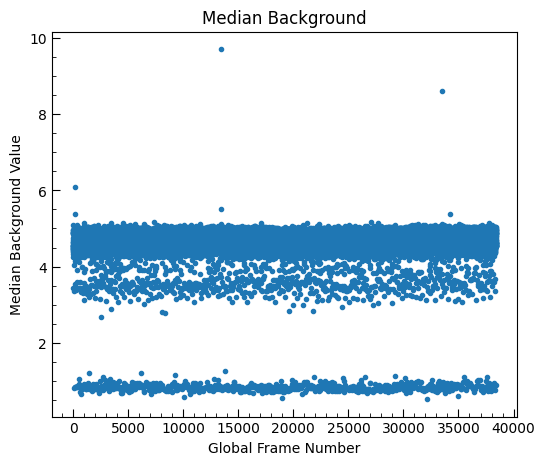

In [93]:
# Median value in each frame

for i in range(totframes):
    med                     = np.median(datacube[i, :, :])
    photometry[i, mbkg_col] = med # adding median value column
    datacube[i, :, :]      -= med # subtract median

# Background vs frame number
plt.figure(figsize=(6, 5))
plt.scatter(photometry[:, glof_col], photometry[:, mbkg_col], marker='.')
plt.xlabel('Global Frame Number')
plt.ylabel('Median Background Value')
plt.title('Median Background')
plt.tick_params(axis='both', direction='in', length=6)
plt.minorticks_on()
plt.tick_params(axis='both', which='minor', direction='in', length=3)
plt.show()

In [94]:
print('Problem 8 \n')

Problem 8 



In [95]:
# Sigma-rejection routine

def sigma_reject(data, sigma, iters, axis):
    """
    Routine to mask values outside standard deviations away from data.

    Parameters
    ----------
    data : ndarray
        array with data to clip
    sigma : int or float
        number of sigma away to start clipping data
    iters : int or float
        number of iterations to clip data through
    axis :
        along which axis to sigma reject
    
    Returns
    -------
        Boolean array where True = good pixel, False = bad pixel
    """
    # Astropy sigma clipping routine
    clipped   = sigma_clip(data, sigma=sigma, maxiters=iters, axis=axis, masked=True)

    # With masked = True, a boolean mask is returned where the clipped values are True
    # So just reverse where True values are not clipped and False are clipped
    bad_mask  = np.ma.getmaskarray(clipped)
    good_mask = ~bad_mask
    
    return np.asarray(good_mask)

In [96]:
print('Problem 9 \n')

Problem 9 



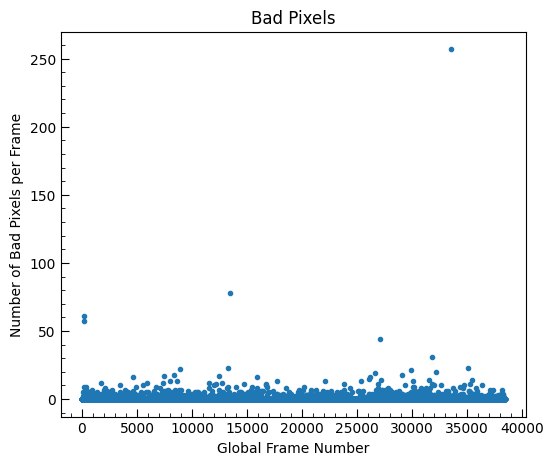

In [97]:
# Find the bad pixels in sets of 64

# Datacube has shape of (totframes, ny, nx)
# But to clip over frames of 64 (without a loop) we can reshape to the number
# of sets (600) which each have 64 frames

nsets  = totframes // nf 
data4d = datacube.reshape(nsets, nf, ny, nx) # reshape datacube for sigma clip per 64 frames

# Sigma clip along the 64 frame axis (axis = 1) within each set
good_clip4d = sigma_reject(data4d, clip_sig, max_iter, clipaxis)

# Reshape the 4D datacube back into 3D
good_clip3d = good_clip4d.reshape(totframes, ny, nx)

# Insert resulting boolean into mask array
# Keeps good pixels true from good
# Makes false pixels bad from sigma_clip
mask       &= good_clip3d

# Bad pixels vs frame number
bad_per_frame = np.sum(~mask, axis=(1, 2))

plt.figure(figsize=(6, 5))
plt.scatter(photometry[:, glof_col], bad_per_frame, marker='.')
plt.xlabel('Global Frame Number')
plt.ylabel('Number of Bad Pixels per Frame')
plt.title('Bad Pixels')
plt.tick_params(axis='both', direction='in', length=6)
plt.minorticks_on()
plt.tick_params(axis='both', which='minor', direction='in', length=3)
plt.show()

In [98]:
print('Problem 10 \n')

Problem 10 



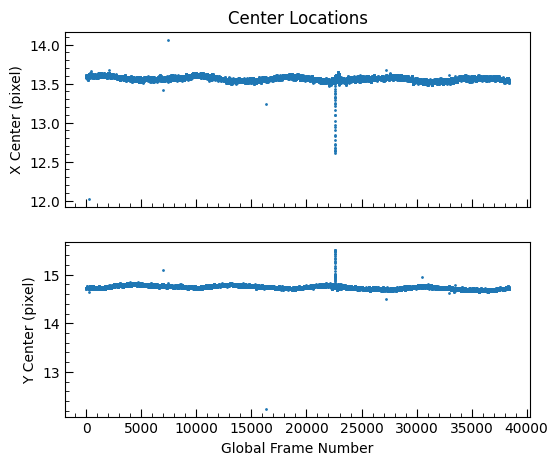

In [99]:
# Approximate location of center of star routine

def fitcenter(data, yguess, xguess, subz):
    """
    Fit 2D Gaussian around a guess pixel center value.

    Parameters
    ----------
    data : ndarray
        data of image/frame
    yguess : int or float
        guess location for the y coordinate in pixels
    xguess : int or float
        guess location for the x coordinate in pixels
    subz : int or float
        width of the image to focus on a section of the whole image
    
    Returns
    -------
        Center coordinate and width of Gaussian (cy, cx, sigma_avg)
    """

    # Subarray
    yg, xg = int(yguess), int(xguess)

    ytop = yg + subz + 1
    ybot = yg - subz
    xtop = xg + subz + 1
    xbot = xg - subz

    sub = data[ybot:ytop, xbot:xtop].copy()
    sub -= np.median(sub)                  # median subtract

    # Fitting relative to subarr (width tuple) (center tuple) (height)
    guess = ((5.0, 5.0), (yg - ybot, xg - xbot), np.max(sub))

    # Gaussian fit
    fw, fc, fh, fe = g.fitgaussian(sub, guess=guess)

    sigma_avg = float((fw[0] + fw[1]) / 2.0)

    # Fitting back to original coords
    cy, cx = float(fc[0] + ybot), float(fc[1] + xbot)

    return cy, cx, sigma_avg

# For the first frame, visually
frame0                  = datacube[0, :, :]
y0, x0                  = 14.7, 13.5
cy0, cx0, sigma         = fitcenter(frame0, y0, x0, ssize)
photometry[0, ycen_col] = cy0
photometry[0, xcen_col] = cx0

# Looping over all images, using previous fitted position as guess
for i in range(1, totframes):
    framei = datacube[i, :, :]
    # Here we use previous fitted position given we have it for frame 0
    yi, xi = photometry[i-1, ycen_col], photometry[i-1, xcen_col]
    cyi, cxi, sigma_i       = fitcenter(framei, yi, xi, ssize)
    photometry[i, ycen_col] = cyi
    photometry[i, xcen_col] = cxi
    photometry[i, widt_col] = sigma_i

# Plot x and y position vs the frame number
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 5))


ax1.plot(photometry[:, xcen_col], '.', ms=2)
ax1.set_ylabel('X Center (pixel)')
ax1.set_title('Center Locations')
ax1.tick_params(axis='both', direction='in', length=6)
ax1.minorticks_on()
ax1.tick_params(axis='both', which='minor', direction='in', length=3)

ax2.plot(photometry[:, ycen_col], '.', ms=2)
ax2.set_ylabel('Y Center (pixel)')
ax2.set_xlabel('Global Frame Number')
ax2.tick_params(axis='both', direction='in', length=6)
ax2.minorticks_on()
ax2.tick_params(axis='both', which='minor', direction='in', length=3)
plt.show()

In [100]:
print('Problem 11 \n')

Problem 11 



In [101]:
# Median combined image of whole dataset
median_image = np.median(datacube, axis=0)

# For offset from main star
ygstar, xgstar      = 14.7, 13.6   # main star
cystar, cxstar, _   = fitcenter(median_image, ygstar, xgstar, ssize)

ygfaint, xgfaint    = 6, 9         # faint star
cyfaint, cxfaint, _ = fitcenter(median_image, ygfaint, xgfaint, ssize)

# Offset in median image
yoff = cyfaint - cystar
xoff = cxfaint - cxstar

print(f'Companion star is offset by a change in y = {yoff} pixels, and a change in x = {xoff} pixels')

# Mask the companion star in each frame
r_mask = 2                    # radius of disk
yy, xx = np.indices((ny, nx)) # coordinate grid

for i in range(totframes):
    # Star center for this frame
    cy = photometry[i, ycen_col]
    cx = photometry[i, xcen_col]

    # Apply offset for companion center
    cy_comp = cy + yoff
    cx_comp = cx + xoff

    # Mask disk to remove companion star
    dist = (yy - cy_comp)**2 + (xx - cx_comp)**2

    # Mark pixels within radius as bad (False)
    mask[i, dist <= r_mask**2] = False

Companion star is offset by a change in y = -8.533992372850541 pixels, and a change in x = -4.191814827187713 pixels


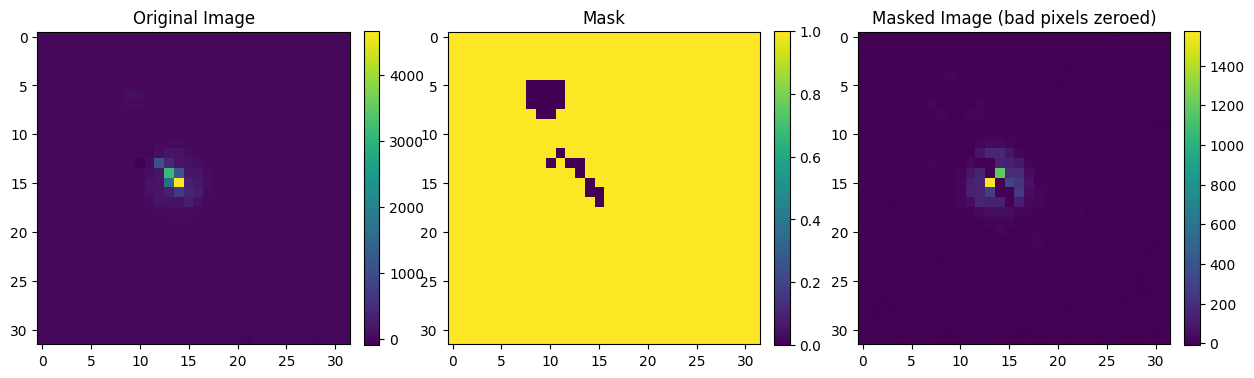

In [102]:
# Testing to ensure mask is working
# This mask should have bad pixels and companion as zero
# With the rest of the image as ones
test = 410

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
im0 = axes[0].imshow(datacube[test])
axes[0].set_title('Original Image')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Bad pixel mask (should have bad pixels and companion as bad)
im1 = axes[1].imshow(mask[test])
axes[1].set_title('Mask')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Masked image
im2 = axes[2].imshow(datacube[test] * mask[test])
axes[2].set_title('Masked Image (bad pixels zeroed)')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()

In [103]:
print('Problem 12 \n')

Problem 12 



In [104]:
# Aperture photometry using HW 10

def aperture_photometry(data, mask, photrad, skyin, skyout, center):
    """
    Parameters
    ----------
    data : ndarray
        data of image/frame
    mask : ndarray
        mask of the data for good and bad pixels
    photrad : int or float
        radius of the aperture
    skyin : int or float
        inner radius of the sky annulus
    skyout : int or float
        outer radius of the sky annulus
    center : tuple
        center coordinates of the star in the image
    Returns
    -------
        array of [flux, average sky, number of bad pixels]
    """
    # No need for a subimage

    # a) use disk to make mask of sky annulus
    skymask  = d.disk( skyout, center, data.shape)^d.disk( skyin, center, data.shape ) 

    # b) apply bad-pixel mask to sky annulus (only good sky pixels)
    good_sky = skymask * mask

    # c) average sky level using only good sky pixels
    skyavg   = np.sum( good_sky * data ) / np.sum( good_sky )

    # d) subtract sky from image
    data_sky_sub = data - skyavg

    # e) aperture mask (do NOT apply bad-pixel mask here)
    apmask   = d.disk(photrad, center, data.shape)
    good_ap  = apmask * mask
    bad_ap   = apmask * ~mask

    # f) total stellar flux in the aperture (sky already subtracted)
    flux     = np.sum( good_ap * data_sky_sub )

    # g) number of bad pixels in the aperture, ~mask is bad pixels
    nbadapt  = np.sum(bad_ap)

    return np.array([flux, skyavg, nbadapt])

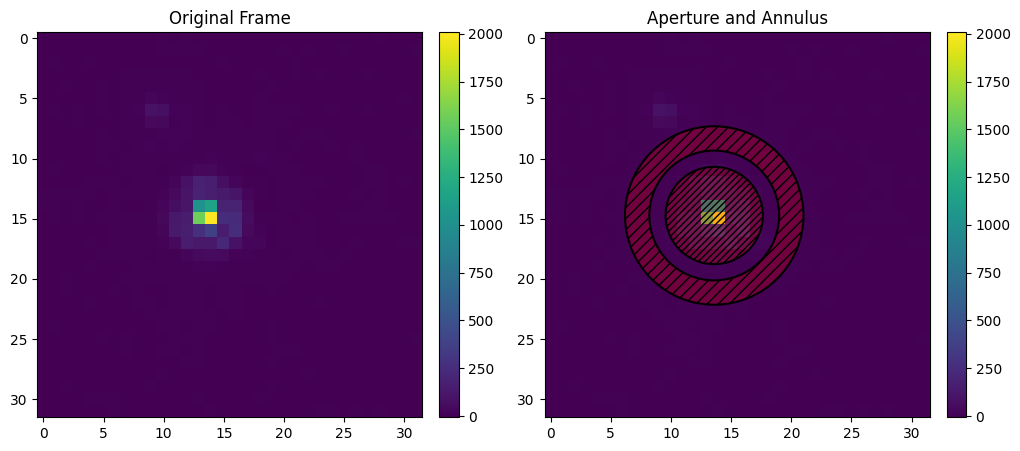

In [105]:
# Testing to see if all the masks look good
# This includes masks for the aperture photometry
test = 900 # 410 is one with bad pixels

# Testing values, these values give the most accruate interpretation
sigmatest   = photometry[test, widt_col]
photradtest = 6.0 * sigmatest 
skyintest   = 8.0 * sigmatest
skyouttest  = 11.0 * sigmatest

cy = photometry[test, ycen_col]
cx = photometry[test, xcen_col]

frame = datacube[test]

# Plot
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))

# Original frame
im0 = ax0.imshow(frame)
ax0.set_title('Original Frame')
fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

# Overlays
im1 = ax1.imshow(frame)
ax1.set_title('Aperture and Annulus')

# Aperture
ap_patch = patches.Circle((cx, cy), photradtest,linewidth=1.5,
                          edgecolor='black', facecolor='none',hatch='///')
ap_patch.set_hatch('/' * 5)
ap_patch.set_facecolor((1,0,0,0.25))
ax1.add_patch(ap_patch)

# Annulus
annulus_patch = patches.Wedge((cx, cy),r=skyouttest, theta1=0, theta2=360,
                              width=skyouttest - skyintest, linewidth=1.5,
                              edgecolor='black', facecolor='none', hatch='///')
annulus_patch.set_facecolor((1,0,0,0.25))
ax1.add_patch(annulus_patch)

fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
plt.show()

In [106]:
print('Problem 13 \n')

Problem 13 



In [107]:
# Loop over all frames and update table
# Store aperture counts(flux), average sky, and number of bad pixels

# Determining from average width
sigall   = np.mean(photometry[:, widt_col])
photrad  = 6.0 * sigall
skyin    = 8.0 * sigall
skyout   = 11.0 * sigall

# Loop
for i in range(totframes):
    # Isolating frames with there respective mask
    frame = datacube[i]
    fmask  = mask[i]

    cy = photometry[i, ycen_col] # center coords
    cx = photometry[i, xcen_col]

    photarr = aperture_photometry(frame, fmask, photrad, skyin, skyout, (cy, cx))
    
    # Updating arrays
    photometry[i, flux_col] = photarr[0]
    photometry[i, asky_col] = photarr[1]
    photometry[i, nbad_col] = photarr[2]

In [108]:
print('Problem 14 \n')

Problem 14 



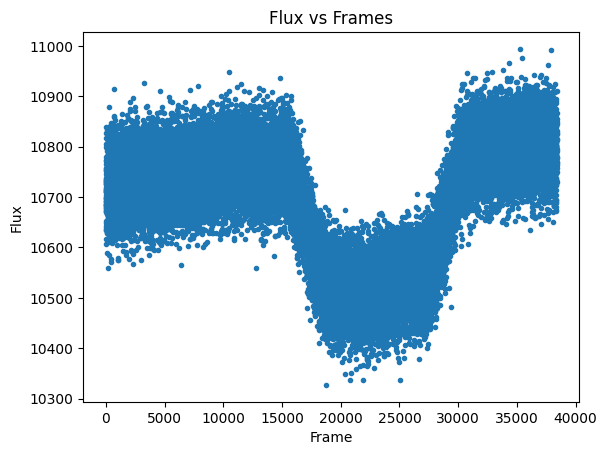

In [109]:
# Check photometry

# Good frames with no bad pixels in them
# If good frame, then no bad pixels in bad_col
goodframes = photometry[:, nbad_col] == 0

plt.figure()
plt.scatter(photometry[goodframes, glof_col], photometry[goodframes, flux_col], marker='.')
plt.xlabel('Frame')
plt.ylabel('Flux')
plt.title('Flux vs Frames')
plt.show()

In [110]:
# There is an apparent transit, but just to be safe, remove outliers

# For frames with a high background
good_sky  = photometry[goodframes, asky_col] # good sky values
sky_med   = np.median(good_sky)
sky_std   = np.std(good_sky)
# Clipping high sky values
high_sky  = (photometry[:, asky_col] > sky_med + 5 * sky_std) & goodframes
# Setting bad_col to -1 for frames with high background
photometry[high_sky, nbad_col] = -1

# For frames with large star motion
y_good    = photometry[goodframes, ycen_col]
x_good    = photometry[goodframes, xcen_col]

y_med = np.median(photometry[goodframes, ycen_col])
x_med = np.median(photometry[goodframes, xcen_col])

dy = photometry[:, ycen_col] - y_med # Difference between y coords
dx = photometry[:, xcen_col] - x_med # Difference between x coords
# Overall radial difference in star motion
# Is an error propagation
dr = np.sqrt(dx**2 + dy**2)

large_motion = (dr > 0.5) & goodframes
photometry[large_motion, nbad_col] = -1

# Recompute good frames after removing outliers
new_good     = photometry[:, nbad_col] == 0
nframes_good = photometry[new_good, glof_col]
nflux_good   = photometry[new_good, flux_col]
nsky_good    = photometry[new_good, asky_col]
ny_good      = photometry[new_good, ycen_col]
nx_good      = photometry[new_good, xcen_col]
nbad_good    = photometry[new_good, nbad_col]

# For comparison against all frames
frames_all   = photometry[:, glof_col]
flux_all     = photometry[:, flux_col]
sky_all      = photometry[:, asky_col]
bad_all      = photometry[:, nbad_col]
y_all        = photometry[:, ycen_col]
x_all        = photometry[:, xcen_col]

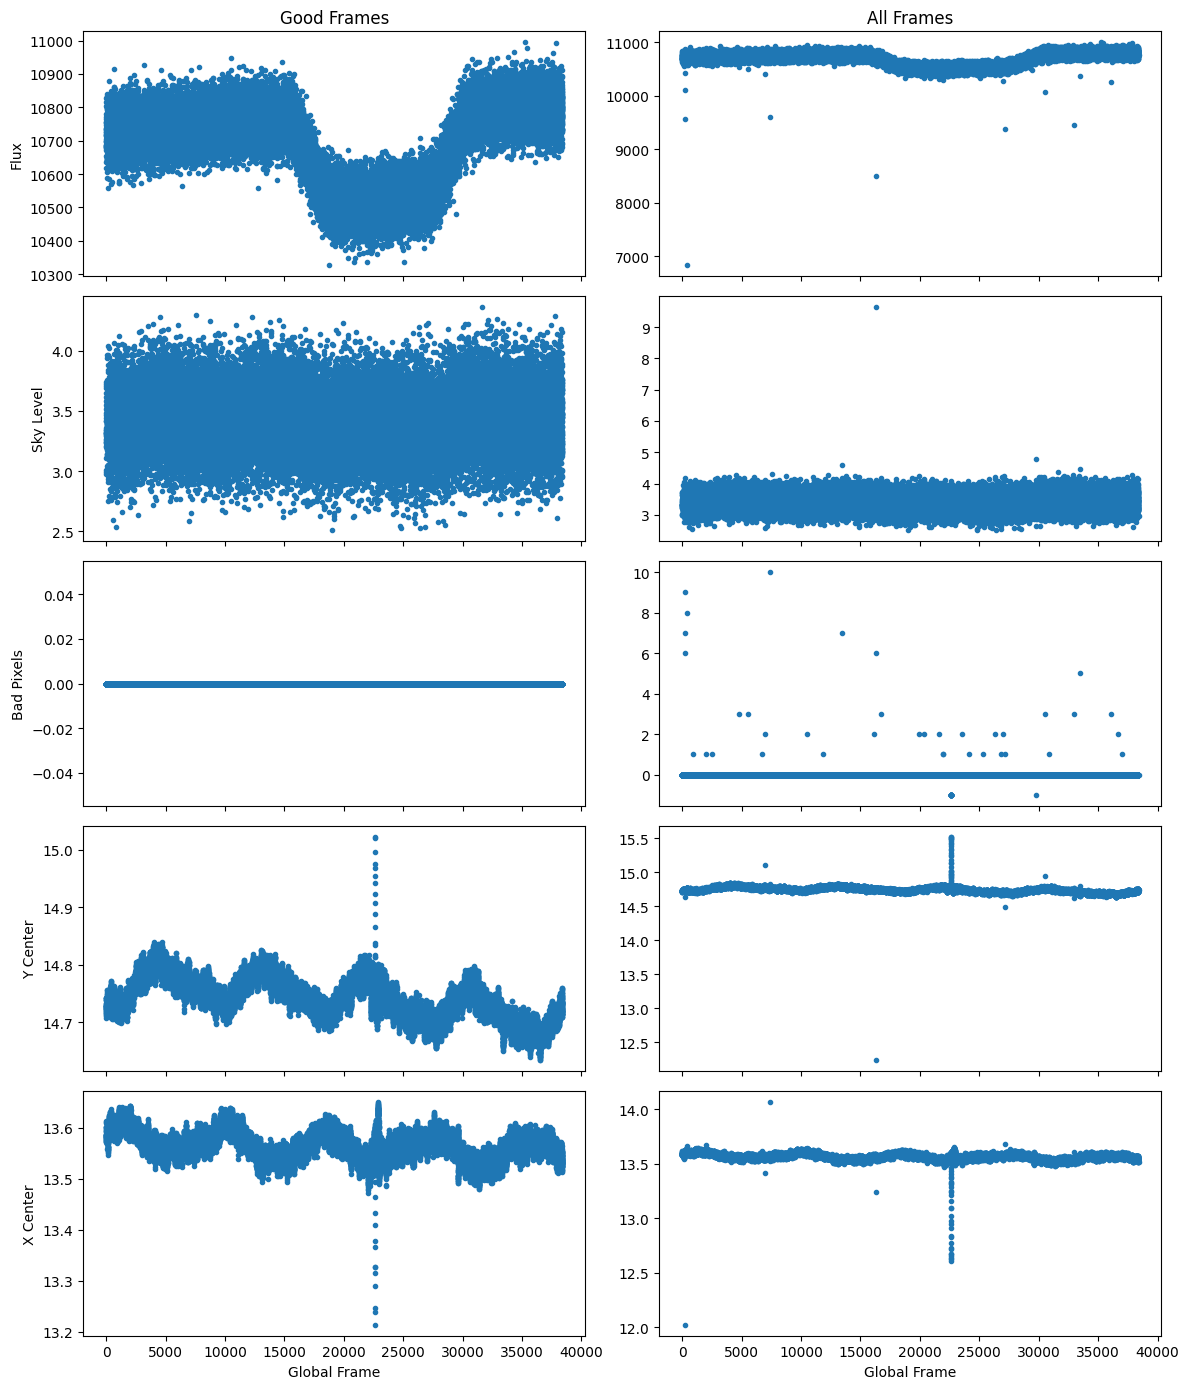

In [111]:
# Plots
fig, axes = plt.subplots(5, 2, figsize=(12, 14), sharex=True)

# Flux
axes[0, 0].plot(nframes_good, nflux_good, '.')
axes[0, 0].set_ylabel('Flux')
axes[0, 0].set_title('Good Frames')

axes[0, 1].plot(frames_all, flux_all, '.')
axes[0, 1].set_title('All Frames')

# Average sky
axes[1, 0].plot(nframes_good, nsky_good, '.')
axes[1, 0].set_ylabel('Sky Level')
axes[1, 1].plot(frames_all, sky_all, '.')

# Bad pixels in aperture
axes[2, 0].plot(nframes_good, nbad_good, '.')
axes[2, 0].set_ylabel('Bad Pixels')
axes[2, 1].plot(frames_all, bad_all, '.')

# Y center
axes[3, 0].plot(nframes_good, ny_good, '.')
axes[3, 0].set_ylabel('Y Center')
axes[3, 1].plot(frames_all, y_all, '.')

# X center
axes[4, 0].plot(nframes_good, nx_good, '.')
axes[4, 0].set_ylabel('X Center')
axes[4, 0].set_xlabel('Global Frame')

axes[4, 1].plot(frames_all, x_all, '.')
axes[4, 1].set_xlabel('Global Frame')

plt.tight_layout()
plt.show()

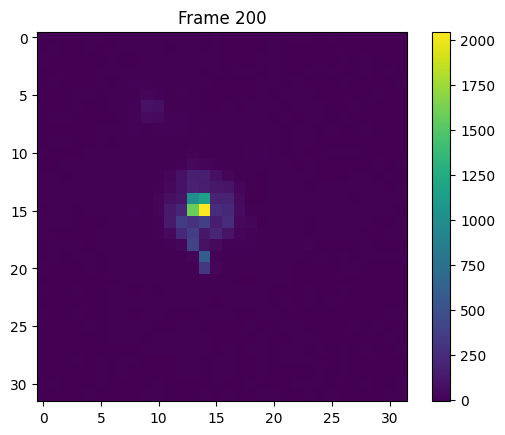

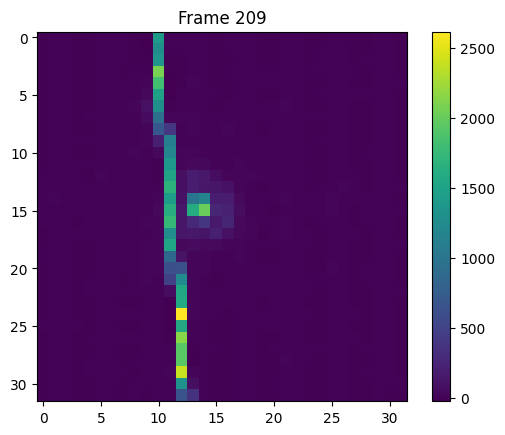

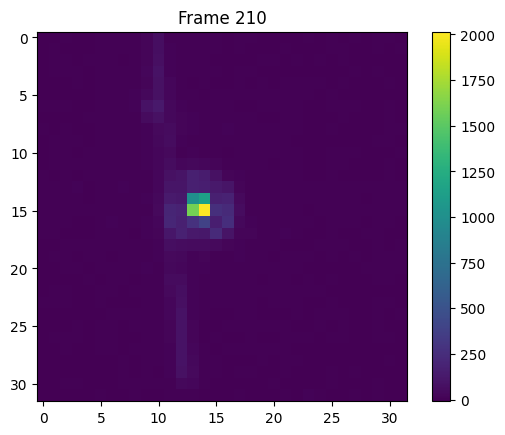

In [112]:
# GOT RID OF THE OUTLIERS

# Frames with at least one bad pixel in aperture
bad = photometry[:, nbad_col] != 0
bad_frames = np.arange(totframes)[bad]

# Plot only the first 3 bad frames
for i in bad_frames[:3]:
    plt.figure()
    plt.imshow(datacube[i])
    plt.title(f'Frame {i}')
    plt.colorbar()
    plt.show()

In [113]:
print('Problem 15 \n')

Problem 15 



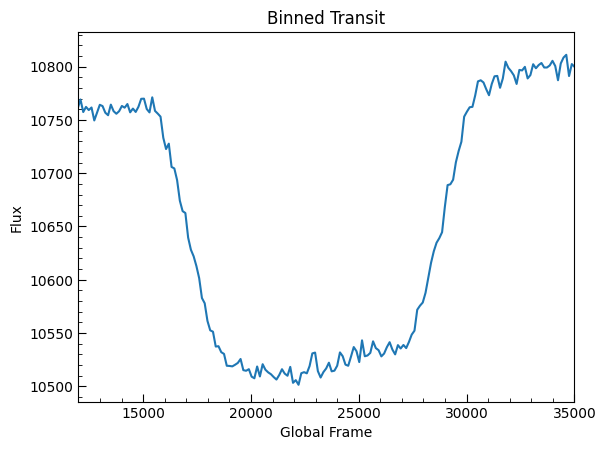

In [114]:
# Bin the data and plot bin averages

# Already have good frames and flux nframes_good and nflux_good
# Corresponding MJD times for good frames
# ngood_time = photometry[new_good, date_col]

N_bins = 300

# Compute weighted sums and counts in each bin using np.histogram
flux_sum,  _      = np.histogram(nframes_good, bins=N_bins, weights=nflux_good)
counts, bin_edges = np.histogram(nframes_good, bins=N_bins)

# Bin centers
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Mean flux per bin
binned_flux = flux_sum / counts

# Plot
plt.figure()
plt.plot(bin_centers, binned_flux)
#plt.xlim(photometry[transit_b, date_col], photometry[transit_e, date_col])
plt.xlim(transit_b, transit_e)
plt.xlabel('Global Frame')
plt.ylabel('Flux')
plt.title('Binned Transit')
plt.tick_params(axis='both', direction='in', length=6)
plt.minorticks_on()
plt.tick_params(axis='both', which='minor', direction='in', length=3)
plt.show()

In [115]:
print('Problem 16 \n')

Problem 16 



In [116]:
# a) start of transit
first_contact  = 16000
# b) planet fully on stellar disk
second_contact = 19100
# c) start of egress
third_contact  = 27500
# d) end of transit
fourth_contact = 30800

print(f'First contact: {first_contact}')
print(f'Second contact: {second_contact}')
print(f'Third contact: {third_contact}')
print(f'Fourth contact: {fourth_contact} \n')

First contact: 16000
Second contact: 19100
Third contact: 27500
Fourth contact: 30800 



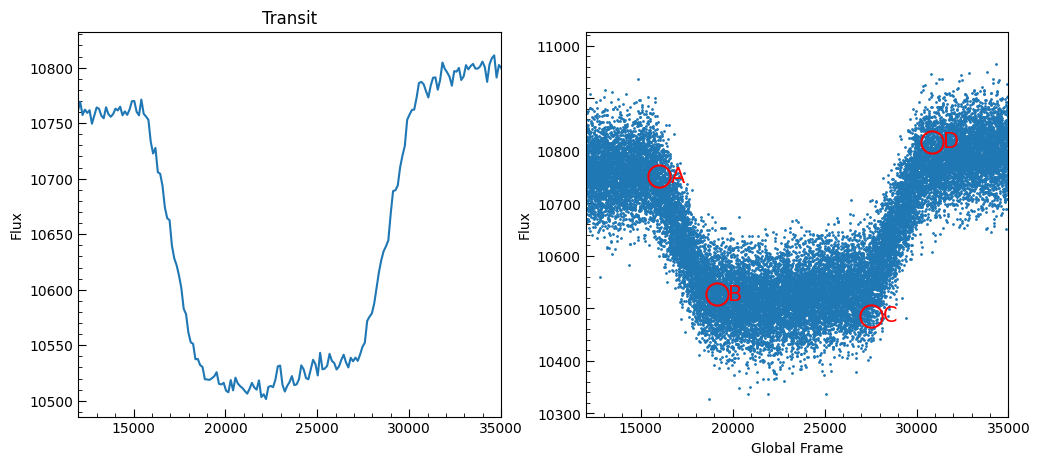

In [117]:
contact_frames = [first_contact, second_contact, third_contact, fourth_contact]
contact_labels = ['A', 'B', 'C', 'D']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Binned
ax1.plot(bin_centers, binned_flux, '-')
ax1.set_ylabel('Flux')
ax1.set_title('Transit')
ax1.set_xlim(transit_b, transit_e)
ax1.tick_params(axis='both', direction='in', length=6)
ax1.minorticks_on()
ax1.tick_params(axis='both', which='minor', direction='in', length=3)

# Transit with contacts
ax2.plot(nframes_good, nflux_good, '.', ms=2)
ax2.set_xlabel('Global Frame')
ax2.set_ylabel('Flux')

# Contact points
for cf, lab in zip(contact_frames, contact_labels):
    x_c = nframes_good[cf]
    y_c = nflux_good[cf]

    ax2.plot(x_c, y_c, marker='o', mfc='none', mec='red',
             mew=1.5, ms=16)

    ax2.text(x_c + 600, y_c, lab, color='red', fontsize=15,
             va='center', ha='left')

ax2.set_xlim(transit_b, transit_e)
ax2.tick_params(axis='both', direction='in', length=6)
ax2.minorticks_on()
ax2.tick_params(axis='both', which='minor', direction='in', length=3)
plt.show()

In [118]:
print('Problem 17 \n')

Problem 17 



C:\Users\Alex\AppData\Local\Temp\ipykernel_29032\1082226320.py:15: RankWarning: Polyfit may be poorly conditioned
  coef       = np.polyfit(out_times, out_flux, 2)


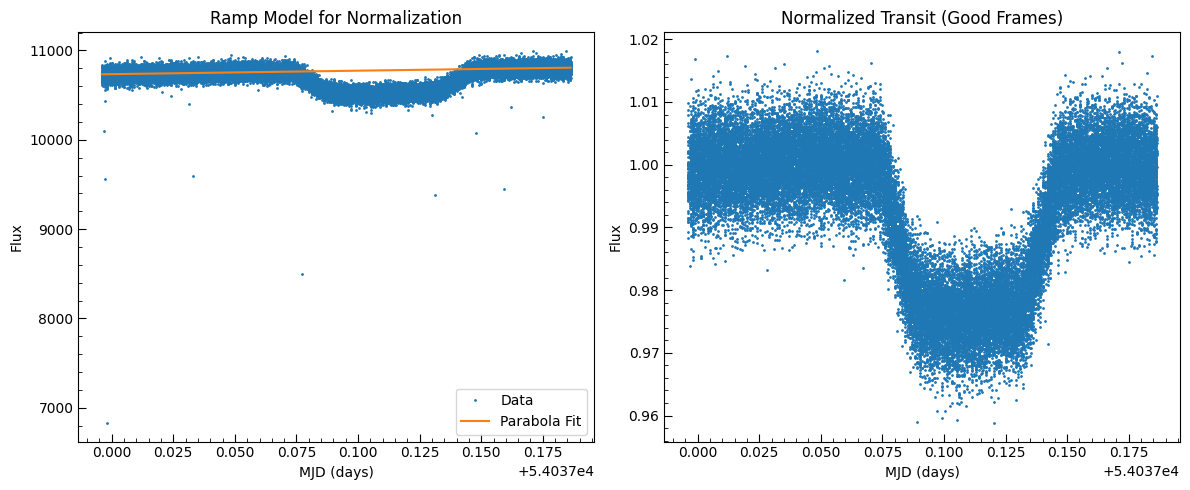

In [119]:
# Fit a parabola to data

# We already have all frames data from above
# BUT I want to start converting to time
times_all = photometry[:, date_col]

# Out of transit for parabola fit
out_transit = (frames_all < transit_b) | (frames_all > transit_e)

# For fit
out_times  = times_all[out_transit]
out_flux   = flux_all[out_transit]

# Fitting parabola f(t) = a * t^2 + b * t + c
coef       = np.polyfit(out_times, out_flux, 2)

# Evaluate ramp model at ALL frames
ramp_model = np.polyval(coef, times_all)

# Normalize all fluxes by the ramp model
flux_norm  = flux_all / ramp_model

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Ramp model
ax1.plot(times_all, flux_all, '.', label='Data', ms=2)
ax1.plot(times_all, ramp_model, '-', label='Parabola Fit')
ax1.set_xlabel('MJD (days)')
ax1.set_ylabel('Flux')
ax1.set_title('Ramp Model for Normalization')
ax1.legend()
ax1.tick_params(axis='both', direction='in', length=6)
ax1.minorticks_on()
ax1.tick_params(axis='both', which='minor', direction='in', length=3)

# NNormalized transit
ax2.plot(times_all[new_good], flux_norm[new_good], '.', ms=2)
ax2.set_xlabel('MJD (days)')
ax2.set_ylabel('Flux')
ax2.set_title('Normalized Transit (Good Frames)')
ax2.tick_params(axis='both', direction='in', length=6)
ax2.minorticks_on()
ax2.tick_params(axis='both', which='minor', direction='in', length=3)

plt.tight_layout()
plt.show()


In [120]:
print('Problem 18 \n')

Problem 18 



In [121]:
# Flat run of normalized frames for S/N

# Transit ends at around 36000 so using the frames after

flatflux = flux_norm[36000:37000]

std_flat = np.std(flatflux) # std of normalized flux for flat region

# For the signal to noise ratio
# Given the data we can use
# S/N = x_bar / sigma where x_bar is the mean and sigma is the std
mean_flat = np.mean(flatflux)

# Gives a flat region S/N of
SNR  = mean_flat / std_flat

print(f'The SNR per frame is: {SNR} \n')

The SNR per frame is: 203.66005649824234 



In [122]:
print('Problem 19 \n')

Problem 19 



In [123]:
# Calculating the ratio

# The good out of transit frames
outf     = (frames_all < 15000) | (frames_all > 31000)
good_out = outf & new_good
flux_out = flux_norm[good_out]

# The good in transit frames (avoiding ingress/egress)
inf      = (frames_all >= 19500) & (frames_all <= 27000)
good_in  = inf & new_good
flux_in  = flux_norm[good_in]

# Averages and uncertainties
avg_fluxout = np.mean(flux_out)
avg_fluxin  = np.mean(flux_in)
std_fluxout = np.std(flux_out)
std_fluxin  = np.std(flux_in)

# Calculating the ratio of the planet cross sectional area to stellar area
# Total flux out of transit F_out proportional to pi * R_star**2

# Total flux when in transit F_in proportional to pi * R_star**2 - pi * R_plan**2

# In taking a ratio of the fluxes, we get rid of proportional and it's an equal since ratios

# F_in / F_out = [ pi * R_star**2 - pi * R_plan**2 ] / pi * R_star**2
#              = 1 - (R_plan**2 / R_star**2)

# I've done some similar complex problems here
# https://github.com/amedina-astr/num_methods_astro/blob/main/num_pset3_AM.ipynb

# solving for planet area over stellar area
# 1 - F_in / F_out = (R_plan**2 / R_star**2)
# R_plan / R_star  = sqrt( 1 - F_in / F_out )
# lets denote with gamma

gamma  = np.sqrt(1 - (avg_fluxin / avg_fluxout))

# For error propagation
dgdin  = - (1 / avg_fluxout)
dgdout = (avg_fluxin / avg_fluxout**2)
dgamma = np.sqrt( (dgdin * std_fluxin)**2 + (dgdout * std_fluxout)**2 )

print(f'The average flux outside transit is: {avg_fluxout}+-{std_fluxout}')
print(f'The average flux inside transit is: {avg_fluxin}+-{std_fluxout}')
print(f'Ratio of planet vs stellar radius (Rp^2/Rs^2): {gamma}+-{dgamma}')

The average flux outside transit is: 1.0000516906450074+-0.0045415973597266405
The average flux inside transit is: 0.9762094823766979+-0.0045415973597266405
Ratio of planet vs stellar radius (Rp^2/Rs^2): 0.15440523278984725+-0.006336029309042191


In [124]:
print('Problem 20 \n')

Problem 20 



In [125]:
# Using article for parameters

Rstar, dRstar = 0.757, 0.003 # in solar rad

# Given the transit depth gamma = Rp / Rs
# Rp = Rs * gamma

Rplan = Rstar * gamma # in solar rad

dRpds = gamma
dRpdg = Rstar

dRplan = np.sqrt( (dRpds * dRstar)**2 + (dRpdg * dgamma)**2 )

# Converting to jupiter radii
Rsun       = 6.96e8 # m
Rplan_m    = Rplan * Rsun
dRplan_m   = dRplan * Rsun

Rjup       = 6.99e7 # m
Rplan_jup  = Rplan_m / Rjup
dRplan_jup = dRplan_m / Rjup

print(f'Radius of the star is {Rstar}+-{dRstar} solar radii')
print(f'The planet radius is {Rplan_jup}+-{dRplan_jup} jupiter radii')
# From the same paper, it is at 1.26 +- 0.03, so in the same magnitude

Radius of the star is 0.757+-0.003 solar radii
The planet radius is 1.16383109886198+-0.047980090105508015 jupiter radii
